# Pattern Recognition - Machine Learning Project2
# Θεοφάνης Μπαρμπαρόσος - 1115202200107

### Dependencies

In [1]:
%pip install matplotlib
%pip install numpy
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Randomness and reproducibility

In [2]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

RANDOM_STATE=42

### EDA (Exploratory Data Analysis)

In [3]:
# General settings for plots

import matplotlib.pyplot as plt

# white background (general)
plt.rcParams['figure.facecolor'] = 'white'
# white background (inside plot)
plt.rcParams['axes.facecolor'] = 'white'
# white background also when saving plots
plt.rcParams['savefig.facecolor'] = 'white'

Number of classes: 4

- Baroque: 1350  samples
- Impressionism: 1350  samples
- Cubism: 1350  samples
- Abstract_Expressionism: 1350  samples

Total: 5400 samples


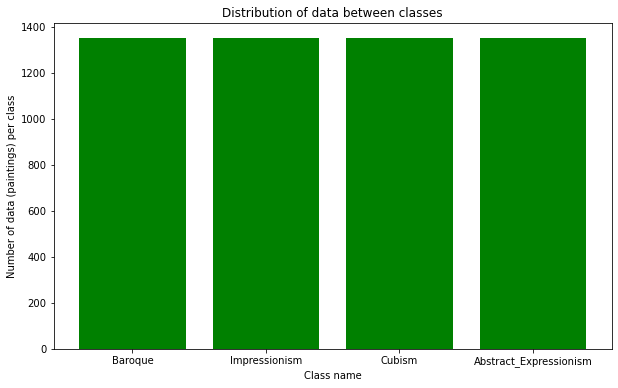

In [4]:
data = np.load('wikiart_hw2.npz')
X = data["X"]
Y = data["y"]
class_names = data["class_names"]

counts = {}
for i in range(4):
    counts[class_names[i]] = np.sum(Y == i)


print(f"Number of classes: {len(class_names)}\n")

for class_name in class_names:
    print(f"- {class_name}: {counts[class_name]}  samples")
print(f"\nTotal: {sum(counts.values())} samples")

plt.figure(figsize=(10,6))
plt.bar(counts.keys(), counts.values(), color='green')
plt.title("Distribution of data between classes")
plt.xlabel("Class name")
plt.ylabel("Number of data (paintings) per class")
plt.show()

### Creating tensors with data

In [6]:
# loading data into tensors
import torch

x_tensor = torch.tensor(X, dtype=torch.float32)
x_tensor = x_tensor.permute(0, 3, 1, 2)

y_tensor = torch.tensor(Y, dtype=torch.int64)

print(f"x tensor: {x_tensor.shape}")
print(f"y tensor: {y_tensor.shape}")

x tensor: torch.Size([5400, 3, 32, 32])
y tensor: torch.Size([5400])


### Train-Val-Test split

Train split: x:torch.Size([3200, 3, 32, 32]) y:torch.Size([3200])
  - Baroque: 800
  - Impressionism: 800
  - Cubism: 800
  - Abstract_Expressionism: 800
Val split:   x:torch.Size([800, 3, 32, 32]) y:torch.Size([800])
  - Baroque: 200
  - Impressionism: 200
  - Cubism: 200
  - Abstract_Expressionism: 200
Test split:  x:torch.Size([1400, 3, 32, 32]) y:torch.Size([1400])
  - Baroque: 350
  - Impressionism: 350
  - Cubism: 350
  - Abstract_Expressionism: 350


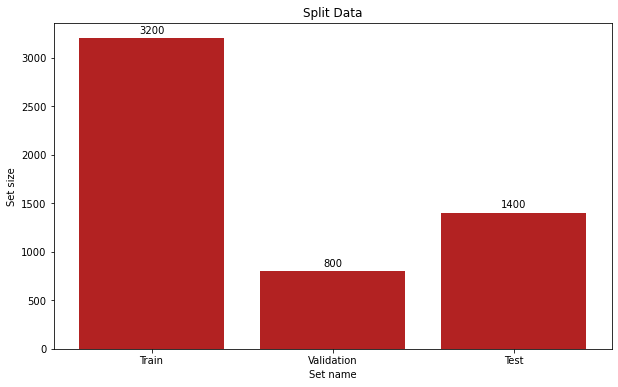

In [21]:
from sklearn.model_selection import train_test_split

# 1st split to create training data
x_train, x_temp, y_train, y_temp = train_test_split(x_tensor, y_tensor, test_size=0.407407407, random_state=42, stratify=y_tensor)

# 2nd split to create validation and test data
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.63636363, random_state=42, stratify=y_temp)

print(f"Train split: x:{x_train.shape} y:{y_train.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_train==i).sum().item()}")
print(f"Val split:   x:{x_val.shape} y:{y_val.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_val==i).sum().item()}")
print(f"Test split:  x:{x_test.shape} y:{y_test.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_test==i).sum().item()}")

plt.figure(figsize=(10, 6))
plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick')
plt.title("Split Data")
plt.xlabel("Set name")
plt.ylabel("Set size")
plt.bar_label(plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick'), padding=3)
plt.show()

### Datasets and dataloaders

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16

# datasets(for dataloaders)
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# debugging
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Train batches: 200
Validation batches: 50
Test batches: 88


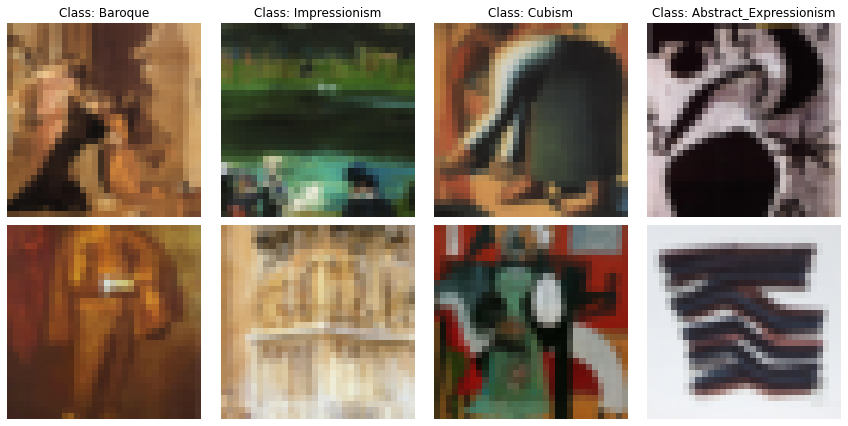

In [ ]:
# a few samples

samples_per_class = {0: [], 1: [], 2: [], 3: []}

for i in range(len(y_tensor)):
    label = y_tensor[i].item()
    if len(samples_per_class[label]) < 2:
        samples_per_class[label].append(x_tensor[i])
    if all(len(images) == 2 for images in samples_per_class.values()):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for class_idx in range(4):
    for sample_idx in range(2):
        img_tensor = samples_per_class[class_idx][sample_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        img_np = np.clip(img_np, 0, 1)
        ax = axes[sample_idx, class_idx]
        ax.imshow(img_np)
        if sample_idx == 0:
            ax.set_title(f"Class: {class_names[class_idx]}")
        ax.axis("off")

plt.tight_layout()
plt.show()